In [1]:
# Imports.
import os
import time
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, Subset
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Device and seed
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)

# CIFAR-10 setup
classes = ["airplane", "automobile", "bird", "cat", "deer","dog", "frog", "horse", "ship", "truck"]

batch_size = 128

basic_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5))])

train_full_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=basic_transform)

test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=basic_transform)

train_size = 45000
val_size = 5000

train_dataset, val_dataset = random_split(
    train_full_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(seed))

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False)

# Helper functions

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def estimate_model_memory_mb(model):
    total_params = count_parameters(model)
    return total_params * 4 / (1024 ** 2)

def train_one_epoch(model, loader, criterion, optimizer, collect_gradients=False):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0
    gradient_norms = {}

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()

        if collect_gradients:
            for name, param in model.named_parameters():
                if param.grad is not None:
                    grad_norm = param.grad.norm().item()

                    if name not in gradient_norms:
                        gradient_norms[name] = []

                    gradient_norms[name].append(grad_norm)

        optimizer.step()

        running_loss += loss.item()

        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    avg_loss = running_loss / len(loader)
    accuracy = 100 * correct / total

    if collect_gradients:
        avg_gradient_norms = {
            name: np.mean(values)
            for name, values in gradient_norms.items()}

        return avg_loss, accuracy, avg_gradient_norms

    return avg_loss, accuracy


def evaluate(model, loader, criterion):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = outputs.max(1)

            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = running_loss / len(loader)
    accuracy = 100 * correct / total

    return avg_loss, accuracy, np.array(all_preds), np.array(all_labels)


def train_model(
    model,
    train_loader,
    eval_loader,
    epochs=15,
    lr=0.001,
    weight_decay=0.0,
    collect_gradients=False
):
    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay)

    history = {
        "train_loss": [],
        "train_acc": [],
        "eval_loss": [],
        "eval_acc": [],
        "gradient_norms": [],
        "training_time": None}

    start_time = time.time()

    for epoch in range(epochs):
        if collect_gradients:
            train_loss, train_acc, grad_norms = train_one_epoch(
                model,
                train_loader,
                criterion,
                optimizer,
                collect_gradients=True)
            history["gradient_norms"].append(grad_norms)
        else:
            train_loss, train_acc = train_one_epoch(
                model,
                train_loader,
                criterion,
                optimizer,
                collect_gradients=False)

        eval_loss, eval_acc, _, _ = evaluate(
            model,
            eval_loader,
            criterion)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["eval_loss"].append(eval_loss)
        history["eval_acc"].append(eval_acc)

        print(
            f"Epoch {epoch + 1:02d}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.2f}% | "
            f"Eval Loss: {eval_loss:.4f} | "
            f"Eval Acc: {eval_acc:.2f}%")

    history["training_time"] = time.time() - start_time

    return history

def plot_learning_curves(history, title):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="Train loss")
    plt.plot(epochs, history["eval_loss"], label="Evaluation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], label="Train accuracy")
    plt.plot(epochs, history["eval_acc"], label="Evaluation accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title("Accuracy")
    plt.legend()

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

def plot_gradient_norms(history, title):
    gradient_norms_per_epoch = history["gradient_norms"]

    if len(gradient_norms_per_epoch) == 0:
        print("No gradient norms were collected.")
        return

    layer_names = list(gradient_norms_per_epoch[0].keys())
    epochs = range(1, len(gradient_norms_per_epoch) + 1)

    plt.figure(figsize=(12, 6))

    for layer_name in layer_names:
        values = []

        for epoch_gradients in gradient_norms_per_epoch:
            values.append(epoch_gradients.get(layer_name, np.nan))

        plt.plot(epochs, values, label=layer_name)

    plt.xlabel("Epoch")
    plt.ylabel("Average gradient norm")
    plt.title(title)
    plt.legend(fontsize=7)
    plt.tight_layout()
    plt.show()

def visualize_cnn_filters(model, title):
    filters = model.conv1.weight.detach().cpu()
    filters = (filters - filters.min()) / (filters.max() - filters.min() + 1e-8)

    num_filters = min(filters.shape[0], 32)

    plt.figure(figsize=(12, 6))

    for i in range(num_filters):
        filt = filters[i]
        filt = filt.permute(1, 2, 0).numpy()

        plt.subplot(4, 8, i + 1)
        plt.imshow(filt)
        plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

def visualize_mlp_weights(model, title):
    weights = model.fc1.weight.detach().cpu()

    num_neurons = min(weights.shape[0], 32)

    plt.figure(figsize=(12, 6))

    for i in range(num_neurons):
        w = weights[i].reshape(3, 32, 32)
        w = w.permute(1, 2, 0).numpy()
        w = (w - w.min()) / (w.max() - w.min() + 1e-8)

        plt.subplot(4, 8, i + 1)
        plt.imshow(w)
        plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

def plot_confusion_matrix_for_model(model, loader, title):
    criterion = nn.CrossEntropyLoss()
    _, acc, preds, labels = evaluate(model, loader, criterion)

    cm = confusion_matrix(labels, preds)

    fig, ax = plt.subplots(figsize=(9, 9))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=classes)

    disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
    plt.title(f"{title}\nAccuracy: {acc:.2f}%")
    plt.tight_layout()
    plt.show()

Using device: cuda


100%|██████████| 170M/170M [00:04<00:00, 40.4MB/s]


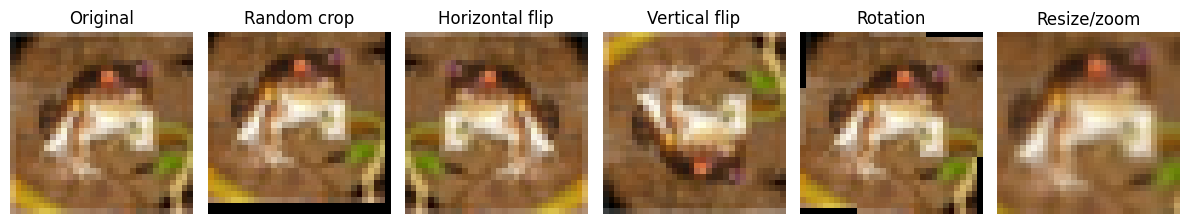

Training CNN without augmentation
Epoch 01/15 | Train Loss: 1.4346 | Train Acc: 47.56% | Eval Loss: 1.0711 | Eval Acc: 61.76%
Epoch 02/15 | Train Loss: 0.9355 | Train Acc: 67.04% | Eval Loss: 0.8910 | Eval Acc: 68.92%
Epoch 03/15 | Train Loss: 0.7272 | Train Acc: 74.75% | Eval Loss: 0.8060 | Eval Acc: 72.18%
Epoch 04/15 | Train Loss: 0.5868 | Train Acc: 79.58% | Eval Loss: 0.8204 | Eval Acc: 72.88%
Epoch 05/15 | Train Loss: 0.4755 | Train Acc: 83.59% | Eval Loss: 0.7145 | Eval Acc: 76.35%
Epoch 06/15 | Train Loss: 0.3785 | Train Acc: 86.78% | Eval Loss: 0.7903 | Eval Acc: 75.48%
Epoch 07/15 | Train Loss: 0.2932 | Train Acc: 89.82% | Eval Loss: 0.7909 | Eval Acc: 76.00%
Epoch 08/15 | Train Loss: 0.2257 | Train Acc: 92.05% | Eval Loss: 0.9197 | Eval Acc: 75.55%
Epoch 09/15 | Train Loss: 0.1834 | Train Acc: 93.59% | Eval Loss: 0.9692 | Eval Acc: 75.57%
Epoch 10/15 | Train Loss: 0.1481 | Train Acc: 94.77% | Eval Loss: 1.0731 | Eval Acc: 75.58%
Epoch 11/15 | Train Loss: 0.1255 | Train Acc: 

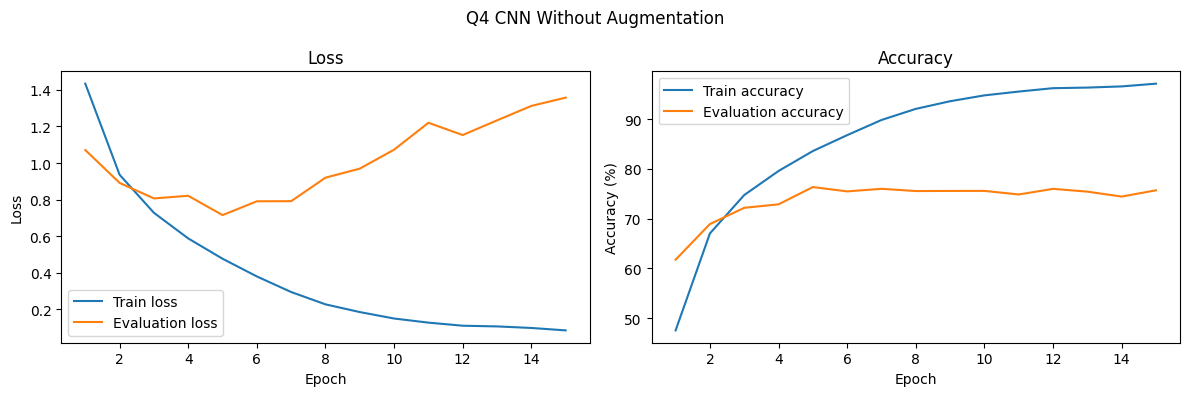

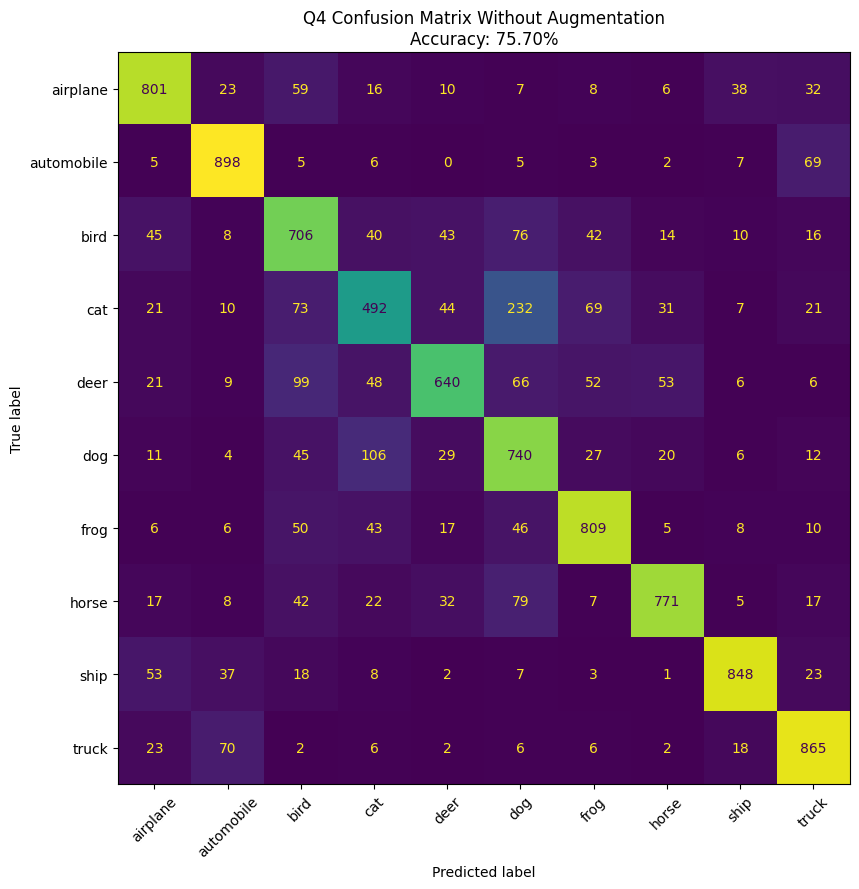

Training CNN with augmentation
Epoch 01/15 | Train Loss: 1.6720 | Train Acc: 38.50% | Eval Loss: 1.3401 | Eval Acc: 51.55%
Epoch 02/15 | Train Loss: 1.3325 | Train Acc: 52.11% | Eval Loss: 1.1360 | Eval Acc: 59.58%
Epoch 03/15 | Train Loss: 1.1770 | Train Acc: 58.07% | Eval Loss: 0.9743 | Eval Acc: 65.83%
Epoch 04/15 | Train Loss: 1.0675 | Train Acc: 62.11% | Eval Loss: 0.9810 | Eval Acc: 65.29%
Epoch 05/15 | Train Loss: 1.0058 | Train Acc: 64.54% | Eval Loss: 0.8780 | Eval Acc: 69.50%
Epoch 06/15 | Train Loss: 0.9476 | Train Acc: 66.71% | Eval Loss: 0.8275 | Eval Acc: 71.51%
Epoch 07/15 | Train Loss: 0.9056 | Train Acc: 68.26% | Eval Loss: 0.8165 | Eval Acc: 71.79%
Epoch 08/15 | Train Loss: 0.8685 | Train Acc: 69.39% | Eval Loss: 0.8085 | Eval Acc: 72.01%
Epoch 09/15 | Train Loss: 0.8316 | Train Acc: 70.70% | Eval Loss: 0.7293 | Eval Acc: 74.72%
Epoch 10/15 | Train Loss: 0.8077 | Train Acc: 71.64% | Eval Loss: 0.7136 | Eval Acc: 75.43%
Epoch 11/15 | Train Loss: 0.7848 | Train Acc: 72.

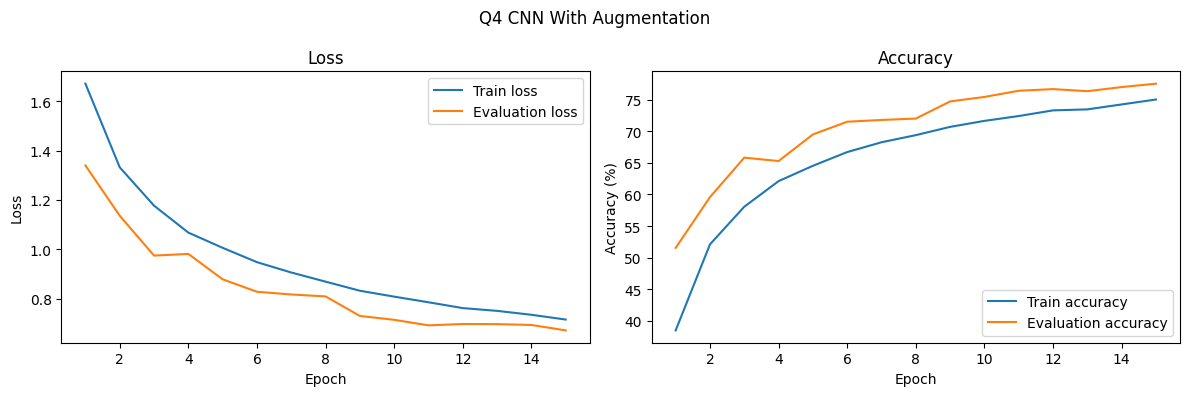

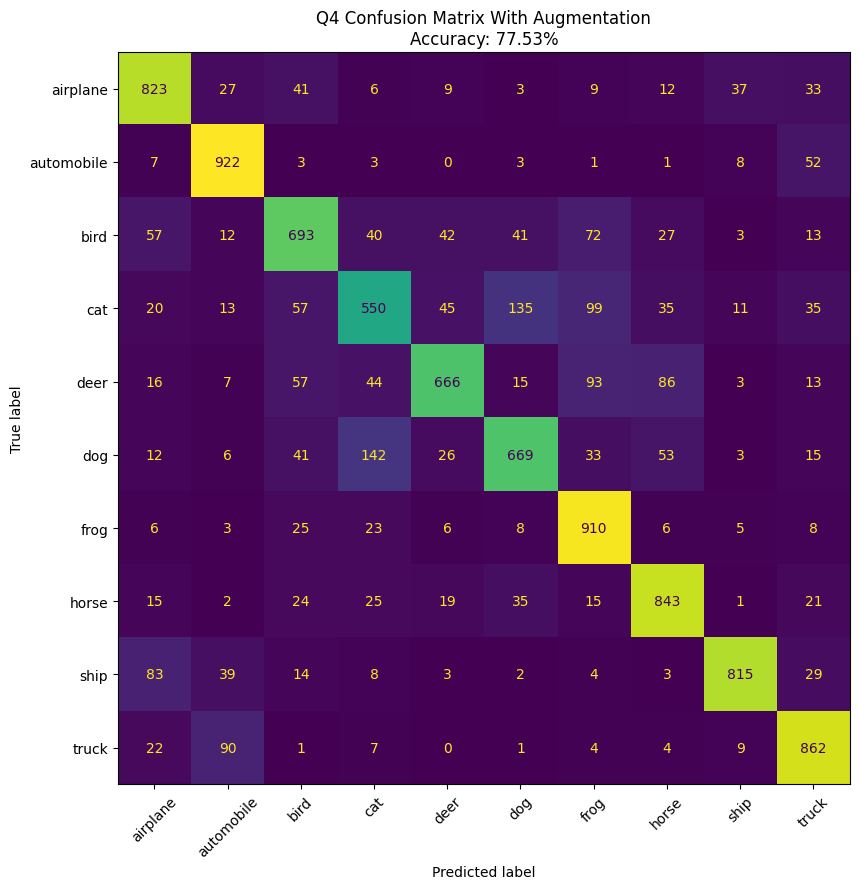


Q4 RESULTS
CNN without augmentation
Train loss: 0.0830400076258899
Train accuracy: 97.118
Test loss: 1.3581883763965172
Test accuracy: 75.7

CNN with augmentation
Train loss: 0.7147224463922593
Train accuracy: 75.026
Test loss: 0.6707447461689575
Test accuracy: 77.53


In [2]:
# QUESTION 4 — augmentation

class ImprovedCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.conv4 = nn.Conv2d(128, 256, 3, padding=1)

        self.fc1 = nn.Linear(256 * 2 * 2, 256)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.max_pool2d(x, 2)

        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)

        x = F.relu(self.conv3(x))
        x = F.max_pool2d(x, 2)

        x = F.relu(self.conv4(x))
        x = F.max_pool2d(x, 2)

        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

def show_augmentation_examples():
    raw_dataset = datasets.CIFAR10(
        root="./data",
        train=True,
        download=True,
        transform=None)

    image, label = raw_dataset[0]

    augmentations = {
    "Original": None,
    "Random crop": transforms.RandomCrop(32, padding=4),
    "Horizontal flip": transforms.RandomHorizontalFlip(p=1.0),
    "Vertical flip": transforms.RandomVerticalFlip(p=1.0),
    "Rotation": transforms.RandomRotation(25),
    "Resize/zoom": transforms.Compose([
        transforms.Resize(40),
        transforms.CenterCrop(32)])}

    plt.figure(figsize=(12, 3))

    for i, (name, aug) in enumerate(augmentations.items()):
        if aug is None:
            aug_img = image
        else:
            aug_img = aug(image)

        plt.subplot(1, len(augmentations), i + 1)
        plt.imshow(aug_img)
        plt.title(name)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_augmentation_examples()
no_aug_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5))])

aug_transform = transforms.Compose([
    transforms.RandomResizedCrop(32, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5))])

train_no_aug_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=no_aug_transform)

train_aug_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=aug_transform)

test_basic_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=no_aug_transform)

train_no_aug_loader = DataLoader(
    train_no_aug_dataset,
    batch_size=batch_size,
    shuffle=True)

train_aug_loader = DataLoader(
    train_aug_dataset,
    batch_size=batch_size,
    shuffle=True)

test_basic_loader = DataLoader(
    test_basic_dataset,
    batch_size=batch_size,
    shuffle=False)

num_epochs = 15

print("Training CNN without augmentation")

cnn_no_aug = ImprovedCNN().to(device)

no_aug_history = train_model(
    model=cnn_no_aug,
    train_loader=train_no_aug_loader,
    eval_loader=test_basic_loader,
    epochs=num_epochs,
    lr=0.001)

plot_learning_curves(
    no_aug_history,
    "Q4 CNN Without Augmentation")

plot_confusion_matrix_for_model(
    cnn_no_aug,
    test_basic_loader,
    "Q4 Confusion Matrix Without Augmentation")

print("Training CNN with augmentation")

cnn_aug = ImprovedCNN().to(device)

aug_history = train_model(
    model=cnn_aug,
    train_loader=train_aug_loader,
    eval_loader=test_basic_loader,
    epochs=num_epochs,
    lr=0.001)

plot_learning_curves(
    aug_history,
    "Q4 CNN With Augmentation")

plot_confusion_matrix_for_model(
    cnn_aug,
    test_basic_loader,
    "Q4 Confusion Matrix With Augmentation")

print("\nQ4 RESULTS")
print("=" * 50)

print("CNN without augmentation")
print("Train loss:", no_aug_history["train_loss"][-1])
print("Train accuracy:", no_aug_history["train_acc"][-1])
print("Test loss:", no_aug_history["eval_loss"][-1])
print("Test accuracy:", no_aug_history["eval_acc"][-1])

print("\nCNN with augmentation")
print("Train loss:", aug_history["train_loss"][-1])
print("Train accuracy:", aug_history["train_acc"][-1])
print("Test loss:", aug_history["eval_loss"][-1])
print("Test accuracy:", aug_history["eval_acc"][-1])